# Report 4: Spacecraft ADCS Homework 4

In [195]:
using LinearAlgebra, StaticArrays, Random, Statistics, DifferentialEquations, PythonPlot

include("safe_mode_gyrostat.jl")

include("environmental_perturbations.jl")

include("orbit_gyrostat_environmental.jl")

include("attitude_control_starling_impl.jl")


3×3 Matrix{Float64}:
 0.249  0.0    0.0
 0.0    0.187  0.02
 0.0    0.02   0.148

## §2 — Environmental Torques

GG torque and atmospheric drag modeled per Lecture 13 (exponential atmosphere, rotating Earth, projected area). Drag chosen over SRP: at 480 km LEO aerodynamic forces dominate radiation pressure. RWP050 actuator limits: 6 mN·m torque, 50 mN·m·s momentum per wheel axis.

### Model Setup

RWP050 reaction wheels (3-axis, \(B_w = I_3\)): 6 mN·m max torque, 50 mN·m·s per axis. Magnetorquer rods: \(|m_{c,i}| \leq 0.1\) A·m², torque \(\perp\mathbf{B}\).

In [196]:
function rotation_quat_between(a::SVector{3,Float64}, b::SVector{3,Float64})
    ua = normalize(a)
    ub = normalize(b)
    c = dot(ua, ub)
    if c >= 0.999999
        return @SVector [1.0, 0.0, 0.0, 0.0]
    elseif c <= -0.999999
        v = abs(ua[1]) < 0.9 ? SVector(1.0, 0.0, 0.0) :
            abs(ua[2]) < 0.9 ? SVector(0.0, 1.0, 0.0) : SVector(0.0, 0.0, 1.0)
        axis = normalize(cross(ua, v))
        return SVector{4,Float64}(0.0, axis[1], axis[2], axis[3])
    else
        axis = normalize(cross(ua, ub))
        angle = acos(clamp(c, -1.0, 1.0))
        qv = axis * sin(angle / 2)
        return @SVector [cos(angle / 2), qv[1], qv[2], qv[3]]
    end
end

function coe_to_eci(a_km, e, inc, raan, argp, nu)
    mu = 398600.4418
    p = a_km * (1 - e^2)
    rn = p / (1 + e * cos(nu))
    r_pqw = rn .* @SVector [cos(nu), sin(nu), 0.0]
    v_pqw = sqrt(mu / p) .* @SVector [-sin(nu), e + cos(nu), 0.0]

    cr, sr = cos(raan), sin(raan)
    ci, si = cos(inc), sin(inc)
    cp, sp = cos(argp), sin(argp)
    R = @SMatrix [
        cr * cp - sr * ci * sp   -cr * sp - sr * ci * cp    sr * si
        sr * cp + cr * ci * sp   -sr * sp + cr * ci * cp   -cr * si
        si * sp                   si * cp                    ci
    ]
    return R * r_pqw, R * v_pqw
end

function compute_sso_inclination(altitude_km)
    mu = 398600.4418
    re = 6378.1363
    j2 = 1.08262668e-3
    omega_dot = 0.985647 * (pi / 180) / 86400
    a = re + altitude_km
    n = sqrt(mu / a^3)
    return acos(clamp(omega_dot / (-1.5 * j2 * n * (re / a)^2), -1.0, 1.0))
end

compute_sso_inclination (generic function with 1 method)

In [197]:

Random.seed!(12345)

I_body = @SMatrix [
    0.249  0.0    0.0
    0.0    0.187  0.02
    0.0    0.02   0.148
]

e_panel = @SVector [0.0, 1.0, 0.0]
omega_des = rpm2rad(10.0)
w_des = omega_des .* e_panel

I_pert = perturb_inertia(I_body; sig_eig=0.03, sig_rot=deg2rad(2.0))
H_r, I_rotor_eff = required_rotor_momentum(I_pert, e_panel; ratio=1.2, omega=omega_des)

# alt_km = 480.0
# re_km = 6378.1363
a_km = re_km + alt_km
inc = compute_sso_inclination(alt_km)
r0_km, v0_kmps = coe_to_eci(a_km, 0.0, inc, 0.0, 0.0, 0.0)

sun_vec_eci = @SVector [1.0, 0.0, 0.0]
q0_orbit = rotation_quat_between(e_panel, sun_vec_eci)

env = EarthEnvironment()
aero = SpacecraftAeroProperties(
    Cd=2.2,
    area_m2=0.03,
    mass_kg=12.0,
    area_normal_body=e_panel,
    center_of_pressure_body_m=SVector(0.02, 0.0, 0.0)
)
srp = SpacecraftSRPProperties(
    Cr=1.3,
    area_m2=0.03,
    area_normal_body=e_panel,
    center_of_pressure_body_m=SVector(0.02, 0.0, 0.0),
    sun_distance_au=1.0,
    eclipse=false
)

#BCT RWP050 (XACT-50) nominal limits
const tau_wheel_max_nm = 6e-3        # max motor torque per wheel [N·m]
const h_wheel_max_nms_per_axis = 50e-3   # saturation per wheel axis [N·m·s]
const n_wheels = 3
const h_wheel_sphere_bound_nms = sqrt(n_wheels) * h_wheel_max_nms_per_axis  # |rho| loose upper norm if each axis saturated
println("omega_des = $(round(omega_des, digits=6)) rad/s")
println("H_r (safe-mode gyrostat storage ref) = $(round(H_r, digits=6)) N*m*s")
println("RWP050: tau_wheel_max = $(tau_wheel_max_nm) N*m, h_wheel_max per axis = $(h_wheel_max_nms_per_axis) N*m*s")
println("Nominal altitude = $(alt_km) km")
cfg = StarlingConfig(
    I_body=I_body,
    e_panel=e_panel,
    alt_km=Float64(alt_km),
    sun_vec_eci=SVector{3,Float64}(sun_vec_eci),
    env=env,
    aero=aero,
    srp=srp,
)

omega_des = 1.047198 rad/s
H_r (safe-mode gyrostat storage ref) = 0.113034 N*m*s
RWP050: tau_wheel_max = 0.006 N*m, h_wheel_max per axis = 0.05 N*m*s
Nominal altitude = 480.0 km


### Single-Point Perturbation Check

Evaluate each torque at the initial orbit condition to verify units and relative magnitudes.

In [198]:
r0_m = 1000.0 .* r0_km
v0_mps = 1000.0 .* v0_kmps

tau_gg = gravity_gradient_torque(I_pert, q0_orbit, r0_m)
F_drag = atmospheric_drag_force(r0_m, v0_mps, q0_orbit, aero; env=env)
tau_drag = atmospheric_drag_torque(r0_m, v0_mps, q0_orbit, aero; env=env)
F_srp = solar_radiation_pressure_force(q0_orbit, sun_vec_eci, srp; env=env)
tau_srp = solar_radiation_pressure_torque(q0_orbit, sun_vec_eci, srp; env=env)

wrench_all = environmental_wrench(
    I_pert,
    q0_orbit,
    r0_m,
    v0_mps;
    sun_eci_m=sun_vec_eci,
    env=env,
    aero=aero,
    srp=srp,
    include_gravity_gradient=true,
    include_drag=true,
    include_srp=true
)

println("gravity gradient torque [N*m] = ", tau_gg)
println("atmospheric drag force [N] = ", F_drag)
println("atmospheric drag torque [N*m] = ", tau_drag)
println("solar radiation pressure force [N] = ", F_srp)
println("solar radiation pressure torque [N*m] = ", tau_srp)
println("combined environmental force [N] = ", wrench_all.force_eci_N)
println("combined environmental torque [N*m] = ", wrench_all.torque_body_Nm)

gravity gradient torque [N*m] = [5.648188350606304e-8, -1.254149750852541e-23, -2.2778332421628314e-9]
atmospheric drag force [N] = [-0.0, 6.862661835964995e-23, -3.5245809525979607e-22]
atmospheric drag torque [N*m] = [-0.0, 7.049161905195921e-24, 3.0476340722018746e-40]
solar radiation pressure force [N] = [-1.7784e-7, -0.0, -0.0]
solar radiation pressure torque [N*m] = [0.0, -0.0, -3.5568000000000004e-9]
combined environmental force [N] = [-1.7784e-7, 6.862661835964995e-23, -3.5245809525979607e-22]
combined environmental torque [N*m] = [5.648188350606304e-8, -5.492335603329489e-24, -5.834633242162831e-9]


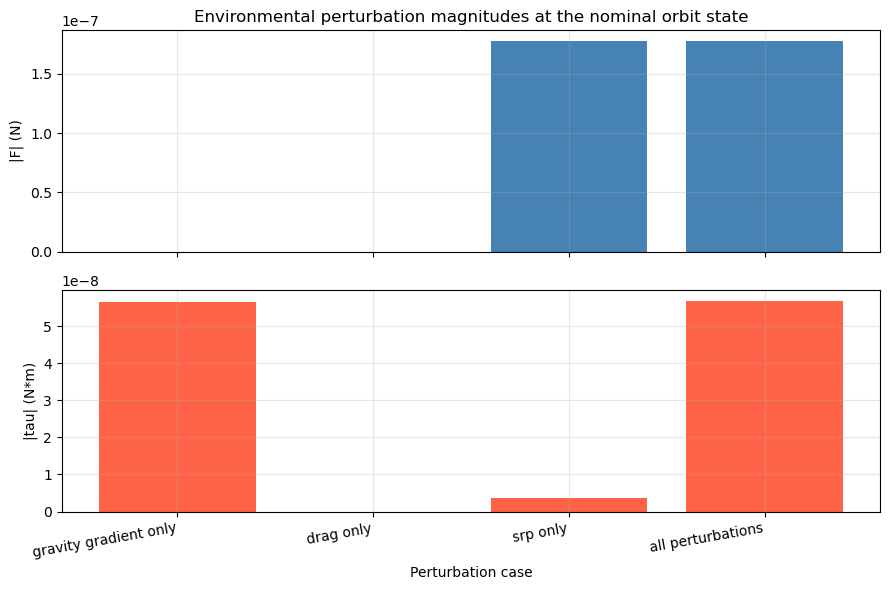

Python: None

In [199]:
cases = [
    ("gravity gradient only", (gg=true,  drag=false, srp=false)),
    ("drag only",             (gg=false, drag=true,  srp=false)),
    ("srp only",              (gg=false, drag=false, srp=true )),
    ("all perturbations",     (gg=true,  drag=true,  srp=true ))
]

torque_norms = Float64[]
force_norms = Float64[]

for (_, flags) in cases
    out = environmental_wrench(
        I_pert,
        q0_orbit,
        r0_m,
        v0_mps;
        sun_eci_m=sun_vec_eci,
        env=env,
        aero=aero,
        srp=srp,
        include_gravity_gradient=flags.gg,
        include_drag=flags.drag,
        include_srp=flags.srp
    )
    push!(force_norms, norm(out.force_eci_N))
    push!(torque_norms, norm(out.torque_body_Nm))
end

labels = [c[1] for c in cases]
x = 1:length(labels)

fig, ax = subplots(2, 1, figsize=(9, 6), sharex=true)
ax[0].bar(x, force_norms, color="steelblue")
ax[0].set_ylabel("|F| (N)")
ax[0].set_title("Environmental perturbation magnitudes at the nominal orbit state")
ax[0].grid(true, alpha=0.3)

ax[1].bar(x, torque_norms, color="tomato")
ax[1].set_ylabel("|tau| (N*m)")
ax[1].set_xticks(collect(x))
ax[1].set_xticklabels(labels, rotation=10, ha="right")
ax[1].grid(true, alpha=0.3)
ax[1].set_xlabel("Perturbation case")

fig.tight_layout()

### Orbit-Wide Torque Profile

In [200]:
function circular_orbit_state(a_km, inc, raan, argp, nu)
    return coe_to_eci(a_km, 0.0, inc, raan, argp, nu)
end

function torque_history_over_orbit(I_body, q_b_to_i, a_km, inc;
        raan=0.0, argp=0.0, sun_vec_eci::SVector{3,Float64}=SVector(1.0, 0.0, 0.0),
        env=EarthEnvironment(), aero=SpacecraftAeroProperties(),
        srp=SpacecraftSRPProperties(), samples=361)

    nus = collect(range(0.0, 2pi; length=samples))
    tau_gg_hist = Vector{SVector{3,Float64}}(undef, samples)
    tau_drag_hist = Vector{SVector{3,Float64}}(undef, samples)
    tau_srp_hist = Vector{SVector{3,Float64}}(undef, samples)

    for k in eachindex(nus)
        r_km, v_kmps = circular_orbit_state(a_km, inc, raan, argp, nus[k])
        r_m = 1000.0 .* r_km
        v_mps = 1000.0 .* v_kmps

        tau_gg_hist[k] = gravity_gradient_torque(I_body, q_b_to_i, r_m)
        tau_drag_hist[k] = atmospheric_drag_torque(r_m, v_mps, q_b_to_i, aero; env=env)
        tau_srp_hist[k] = solar_radiation_pressure_torque(q_b_to_i, sun_vec_eci, srp; env=env)
    end

    return (; nus, tau_gg_hist, tau_drag_hist, tau_srp_hist)
end

function vector_norm_history(vec_hist)
    return [norm(v) for v in vec_hist]
end

function max_with_location(values, locations)
    idx = argmax(values)
    return (; value=values[idx], index=idx, location=locations[idx])
end

max_with_location (generic function with 1 method)

In [201]:
torque_data = torque_history_over_orbit(
    I_pert,
    q0_orbit,
    a_km,
    inc;
    raan=0.0,
    argp=0.0,
    sun_vec_eci=sun_vec_eci,
    env=env,
    aero=aero,
    srp=srp,
    samples=361
)

gg_norm = vector_norm_history(torque_data.tau_gg_hist)
drag_norm = vector_norm_history(torque_data.tau_drag_hist)
srp_norm = vector_norm_history(torque_data.tau_srp_hist)

gg_max = max_with_location(gg_norm, torque_data.nus)
drag_max = max_with_location(drag_norm, torque_data.nus)
srp_max = max_with_location(srp_norm, torque_data.nus)

println("Maximum gravity gradient torque magnitude [N*m] = ", gg_max.value)
println("  occurs near true anomaly [deg] = ", gg_max.location * 180 / pi)
println("Maximum atmospheric drag torque magnitude [N*m] = ", drag_max.value)
println("  occurs near true anomaly [deg] = ", drag_max.location * 180 / pi)
println("Maximum SRP torque magnitude [N*m] = ", srp_max.value)
println("  occurs near true anomaly [deg] = ", srp_max.location * 180 / pi)

perturb_labels = ["gravity gradient", "drag", "srp"]
peak_tau_vals = [gg_max.value, drag_max.value, srp_max.value]
println("\n--- ADCS4 Sec.12: peak |tau| vs RWP050 rated wheel torque ---")
println("tau_wheel_max = ", tau_wheel_max_nm, " N*m")
for k in eachindex(perturb_labels)
    r = peak_tau_vals[k] / tau_wheel_max_nm
    println("  ", perturb_labels[k], ": max |tau| = ", peak_tau_vals[k], " N*m  (~", round(r; sigdigits=4), " * tau_wheel_max)")
end

Maximum gravity gradient torque magnitude [N*m] = 8.770765926678244e-8
  occurs near true anomaly [deg] = 70.0
Maximum atmospheric drag torque magnitude [N*m] = 1.6852647132697933e-7
  occurs near true anomaly [deg] = 90.0
Maximum SRP torque magnitude [N*m] = 3.5568000000000004e-9
  occurs near true anomaly [deg] = 0.0

--- ADCS4 Sec.12: peak |tau| vs RWP050 rated wheel torque ---
tau_wheel_max = 0.006 N*m
  gravity gradient: max |tau| = 8.770765926678244e-8 N*m  (~1.462e-5 * tau_wheel_max)
  drag: max |tau| = 1.6852647132697933e-7 N*m  (~2.809e-5 * tau_wheel_max)
  srp: max |tau| = 3.5568000000000004e-9 N*m  (~5.928e-7 * tau_wheel_max)


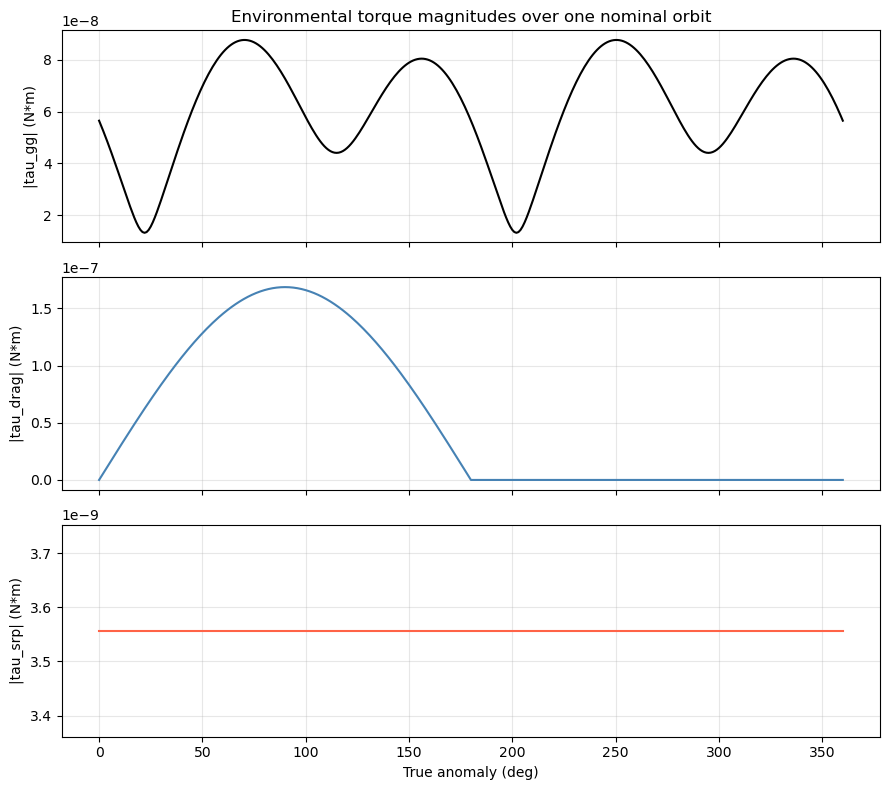

Python: None

In [202]:
nu_deg = torque_data.nus .* 180 ./ pi

fig_torque, ax_torque = subplots(3, 1, figsize=(9, 8), sharex=true)
ax_torque[0].plot(nu_deg, gg_norm, color="black")
ax_torque[0].set_ylabel("|tau_gg| (N*m)")
ax_torque[0].set_title("Environmental torque magnitudes over one nominal orbit")
ax_torque[0].grid(true, alpha=0.3)

ax_torque[1].plot(nu_deg, drag_norm, color="steelblue")
ax_torque[1].set_ylabel("|tau_drag| (N*m)")
ax_torque[1].grid(true, alpha=0.3)

ax_torque[2].plot(nu_deg, srp_norm, color="tomato")
ax_torque[2].set_ylabel("|tau_srp| (N*m)")
ax_torque[2].set_xlabel("True anomaly (deg)")
ax_torque[2].grid(true, alpha=0.3)

fig_torque.tight_layout()

### Orbit-Averaged Torque and 1-Day \(|\Delta H|\)

Secular estimate: \(\|\bar{\tau}\| \times 86400\) s. Upper bound: \(\tau_{\max} \times 86400\) s (pessimistic, assumes persistent peak).

In [203]:
function orbit_period_seconds(a_km; mu_km3s2=398600.4418)
    return 2pi * sqrt(a_km^3 / mu_km3s2)
end

function average_vector_over_orbit(vec_hist)
    total = zero(vec_hist[1])
    for v in vec_hist
        total += v
    end
    return total / length(vec_hist)
end

function average_scalar_over_orbit(values)
    return sum(values) / length(values)
end

function cumulative_delta_h_from_torque_profile(torque_norm_hist, orbit_period_s; day_s=86400.0)
    t_orbit = collect(range(0.0, orbit_period_s; length=length(torque_norm_hist)))
    t_day = collect(range(0.0, day_s; length=1000))
    tau_day = [torque_norm_hist[clamp(1 + floor(Int, (mod(t, orbit_period_s) / orbit_period_s) * (length(torque_norm_hist) - 1)), 1, length(torque_norm_hist))] for t in t_day]
    delta_h_day = zeros(length(t_day))
    for k in 2:length(t_day)
        dt = t_day[k] - t_day[k - 1]
        delta_h_day[k] = delta_h_day[k - 1] + 0.5 * (tau_day[k] + tau_day[k - 1]) * dt
    end
    return (; t_day, tau_day, delta_h_day, t_orbit)
end

cumulative_delta_h_from_torque_profile (generic function with 1 method)

In [204]:
orbit_period_s = orbit_period_seconds(a_km)
orbits_per_day = 86400.0 / orbit_period_s

tau_gg_avg_vec = average_vector_over_orbit(torque_data.tau_gg_hist)
tau_drag_avg_vec = average_vector_over_orbit(torque_data.tau_drag_hist)
tau_srp_avg_vec = average_vector_over_orbit(torque_data.tau_srp_hist)

tau_gg_avg_mag = average_scalar_over_orbit(gg_norm)
tau_drag_avg_mag = average_scalar_over_orbit(drag_norm)
tau_srp_avg_mag = average_scalar_over_orbit(srp_norm)

delta_h_gg_day_secular = norm(tau_gg_avg_vec) * 86400.0
delta_h_drag_day_secular = norm(tau_drag_avg_vec) * 86400.0
delta_h_srp_day_secular = norm(tau_srp_avg_vec) * 86400.0

delta_h_gg_day_upper = gg_max.value * 86400.0
delta_h_drag_day_upper = drag_max.value * 86400.0
delta_h_srp_day_upper = srp_max.value * 86400.0

println("Orbit period [s] = ", orbit_period_s)
println("Orbits per day = ", orbits_per_day)
println()
println("Gravity gradient average torque vector [N*m] = ", tau_gg_avg_vec)
println("Gravity gradient average torque magnitude over orbit [N*m] = ", tau_gg_avg_mag)
println("Gravity gradient one-day secular |Delta H| [N*m*s] = ", delta_h_gg_day_secular)
println("Gravity gradient one-day conservative upper bound |Delta H| [N*m*s] = ", delta_h_gg_day_upper)
println()
println("Atmospheric drag average torque vector [N*m] = ", tau_drag_avg_vec)
println("Atmospheric drag average torque magnitude over orbit [N*m] = ", tau_drag_avg_mag)
println("Atmospheric drag one-day secular |Delta H| [N*m*s] = ", delta_h_drag_day_secular)
println("Atmospheric drag one-day conservative upper bound |Delta H| [N*m*s] = ", delta_h_drag_day_upper)
println()
println("Solar radiation pressure average torque vector [N*m] = ", tau_srp_avg_vec)
println("Solar radiation pressure average torque magnitude over orbit [N*m] = ", tau_srp_avg_mag)
println("Solar radiation pressure one-day secular |Delta H| [N*m*s] = ", delta_h_srp_day_secular)
println("Solar radiation pressure one-day conservative upper bound |Delta H| [N*m*s] = ", delta_h_srp_day_upper)

Orbit period [s] = 5652.234202094749
Orbits per day = 15.285990797759174

Gravity gradient average torque vector [N*m] = [4.707762647469387e-10, 2.2989440878383473e-8, 2.438400569580917e-9]
Gravity gradient average torque magnitude over orbit [N*m] = 6.037411518384473e-8
Gravity gradient one-day secular |Delta H| [N*m*s] = 0.001997843436187556
Gravity gradient one-day conservative upper bound |Delta H| [N*m*s] = 0.0075779417606500026

Atmospheric drag average torque vector [N*m] = [0.0, 1.8784662166460328e-25, 4.201490974910817e-8]
Atmospheric drag average torque magnitude over orbit [N*m] = 5.320237534792573e-8
Atmospheric drag one-day secular |Delta H| [N*m*s] = 0.0036300882023229462
Atmospheric drag one-day conservative upper bound |Delta H| [N*m*s] = 0.014560687122651014

Solar radiation pressure average torque vector [N*m] = [0.0, 0.0, -3.5568000000000322e-9]
Solar radiation pressure average torque magnitude over orbit [N*m] = 3.5568000000000004e-9
Solar radiation pressure one-day

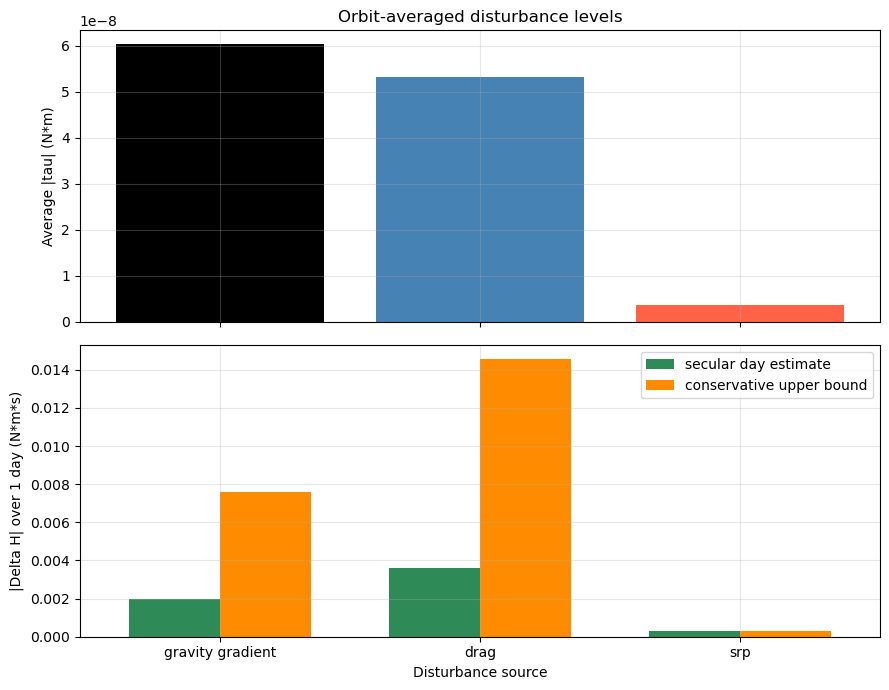

In [205]:
summary_labels = ["gravity gradient", "drag", "srp"]
avg_mag_values = [tau_gg_avg_mag, tau_drag_avg_mag, tau_srp_avg_mag]
secular_day_values = [delta_h_gg_day_secular, delta_h_drag_day_secular, delta_h_srp_day_secular]
upper_day_values = [delta_h_gg_day_upper, delta_h_drag_day_upper, delta_h_srp_day_upper]
x = 1:length(summary_labels)

fig_avg, ax_avg = subplots(2, 1, figsize=(9, 7), sharex=true)
ax_avg[0].bar(x, avg_mag_values, color=["black", "steelblue", "tomato"])
ax_avg[0].set_ylabel("Average |tau| (N*m)")
ax_avg[0].set_title("Orbit-averaged disturbance levels")
ax_avg[0].grid(true, alpha=0.3)

bar_width = 0.35
ax_avg[1].bar((x .- bar_width ./ 2), secular_day_values, width=bar_width, label="secular day estimate", color="seagreen")
ax_avg[1].bar((x .+ bar_width ./ 2), upper_day_values, width=bar_width, label="conservative upper bound", color="darkorange")
ax_avg[1].set_ylabel("|Delta H| over 1 day (N*m*s)")
ax_avg[1].set_xticks(collect(x))
ax_avg[1].set_xticklabels(summary_labels)
ax_avg[1].legend(loc="upper right")
ax_avg[1].grid(true, alpha=0.3)
ax_avg[1].set_xlabel("Disturbance source")

fig_avg.tight_layout()

savefig("figs/orbitaverageddisturbance.png", bbox_inches="tight")
display(fig_avg)


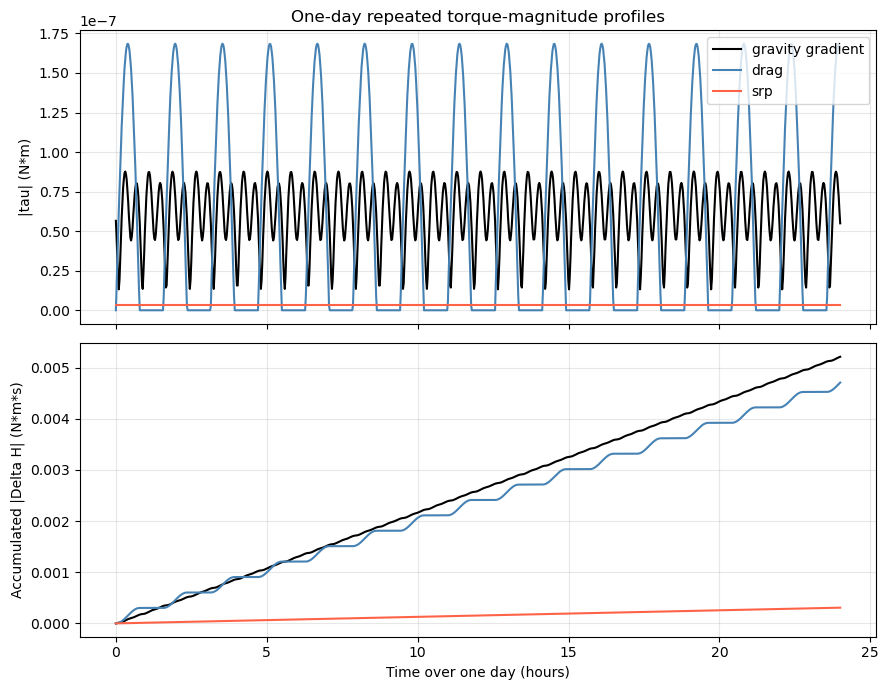

Python: None

In [206]:
gg_day = cumulative_delta_h_from_torque_profile(gg_norm, orbit_period_s)
drag_day = cumulative_delta_h_from_torque_profile(drag_norm, orbit_period_s)
srp_day = cumulative_delta_h_from_torque_profile(srp_norm, orbit_period_s)

fig_day, ax_day = subplots(2, 1, figsize=(9, 7), sharex=true)
ax_day[0].plot(gg_day.t_day ./ 3600.0, gg_day.tau_day, label="gravity gradient", color="black")
ax_day[0].plot(drag_day.t_day ./ 3600.0, drag_day.tau_day, label="drag", color="steelblue")
ax_day[0].plot(srp_day.t_day ./ 3600.0, srp_day.tau_day, label="srp", color="tomato")
ax_day[0].set_ylabel("|tau| (N*m)")
ax_day[0].set_title("One-day repeated torque-magnitude profiles")
ax_day[0].legend(loc="upper right")
ax_day[0].grid(true, alpha=0.3)

ax_day[1].plot(gg_day.t_day ./ 3600.0, gg_day.delta_h_day, label="gravity gradient", color="black")
ax_day[1].plot(drag_day.t_day ./ 3600.0, drag_day.delta_h_day, label="drag", color="steelblue")
ax_day[1].plot(srp_day.t_day ./ 3600.0, srp_day.delta_h_day, label="srp", color="tomato")
ax_day[1].set_ylabel("Accumulated |Delta H| (N*m*s)")
ax_day[1].set_xlabel("Time over one day (hours)")
ax_day[1].grid(true, alpha=0.3)

fig_day.tight_layout()

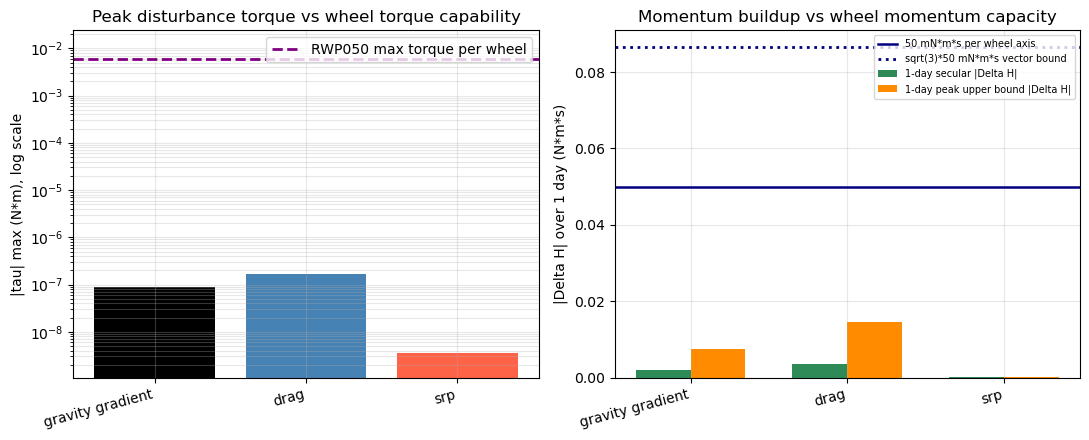

Python: None

In [207]:
# ADCS4 Section 12 sizing: compare disturbances to RWP050 wheel torque / momentum
fig_s12, axs = subplots(1, 2, figsize=(11, 4.5))
xpos = 1:3
bw = 0.35

axs[0].bar(xpos, peak_tau_vals, color=["black", "steelblue", "tomato"])
axs[0].axhline(tau_wheel_max_nm, color="purple", linestyle="--", linewidth=2, label="RWP050 max torque per wheel")
axs[0].set_yscale("log")
flo = minimum(peak_tau_vals)
axs[0].set_ylim(flo > 0 ? (0.3 * flo) : (1e-12), tau_wheel_max_nm * 4)
axs[0].set_xticks(collect(xpos))
axs[0].set_xticklabels(perturb_labels, rotation=15, ha="right")
axs[0].set_ylabel("|tau| max (N*m), log scale")
axs[0].set_title("Peak disturbance torque vs wheel torque capability")
axs[0].legend(loc="upper right")
axs[0].grid(true, alpha=0.3, which="both")

sec = [delta_h_gg_day_secular, delta_h_drag_day_secular, delta_h_srp_day_secular]
upb = [delta_h_gg_day_upper, delta_h_drag_day_upper, delta_h_srp_day_upper]
axs[1].bar(xpos .- bw ./ 2, sec, width=bw, label="1-day secular |Delta H|", color="seagreen")
axs[1].bar(xpos .+ bw ./ 2, upb, width=bw, label="1-day peak upper bound |Delta H|", color="darkorange")
axs[1].axhline(h_wheel_max_nms_per_axis, color="navy", linestyle="-", linewidth=1.8, label="50 mN*m*s per wheel axis")
axs[1].axhline(h_wheel_sphere_bound_nms, color="navy", linestyle=":", linewidth=2, label="sqrt(3)*50 mN*m*s vector bound")
axs[1].set_xticks(collect(xpos))
axs[1].set_xticklabels(perturb_labels, rotation=15, ha="right")
axs[1].set_ylabel("|Delta H| over 1 day (N*m*s)")
axs[1].set_title("Momentum buildup vs wheel momentum capacity")
axs[1].legend(loc="upper right", fontsize=7)
axs[1].grid(true, alpha=0.3)
fig_s12.tight_layout()


### Actuator Implications

Peak \(|\tau|\) sets instantaneous rejection requirement (vs 6 mN·m wheel limit). Secular \(|\Delta H|\) per day sets momentum-dump cadence (vs 50 mN·m·s per-axis saturation). Magnetorquer dumping not sized here (\(\tau_c \perp \mathbf{B}\), orbit-dependent).

In [208]:
function dump_interval_days(momentum_capacity, daily_delta_h)
    if daily_delta_h <= 0.0
        return Inf
    end
    return momentum_capacity / daily_delta_h
end

secular_day_values = [delta_h_gg_day_secular, delta_h_drag_day_secular, delta_h_srp_day_secular]
upper_day_values = [delta_h_gg_day_upper, delta_h_drag_day_upper, delta_h_srp_day_upper]
max_torque_values = [gg_max.value, drag_max.value, srp_max.value]
avg_torque_values = [tau_gg_avg_mag, tau_drag_avg_mag, tau_srp_avg_mag]

dominant_peak_idx = argmax(max_torque_values)
dominant_secular_idx = argmax(secular_day_values)

peak_source = summary_labels[dominant_peak_idx]
secular_source = summary_labels[dominant_secular_idx]

# Gyrostat safe-mode reference
dump_days_Hr_secular = [dump_interval_days(H_r, x) for x in secular_day_values]
dump_days_Hr_upper = [dump_interval_days(H_r, x) for x in upper_day_values]
# ADCS4 RWP050: per-axis wheel saturation vs daily momentum growth
dump_days_wheel_axis_secular = [dump_interval_days(h_wheel_max_nms_per_axis, x) for x in secular_day_values]
dump_days_wheel_axis_upper = [dump_interval_days(h_wheel_max_nms_per_axis, x) for x in upper_day_values]
dump_days_sphere_secular = [dump_interval_days(h_wheel_sphere_bound_nms, x) for x in secular_day_values]
dump_days_sphere_upper = [dump_interval_days(h_wheel_sphere_bound_nms, x) for x in upper_day_values]

dump_orbits_Hr_secular = dump_days_Hr_secular .* orbits_per_day
dump_orbits_Hr_upper = dump_days_Hr_upper .* orbits_per_day

println("--- Momentum reference capacities [N*m*s]")
println("H_r safe-mode rotor reference = ", H_r)
println("h_wheel_max per wheel axis (RWP050) = ", h_wheel_max_nms_per_axis)
println("sqrt(3)*h_wheel_max spherical bound |rho| = ", h_wheel_sphere_bound_nms)
println()
println("Dominant peak-torque disturbance source = ", peak_source)
println("Dominant secular momentum-accumulation source = ", secular_source)
println()
for k in eachindex(summary_labels)
    println(summary_labels[k], ":")
    println("  average torque magnitude over orbit [N*m] = ", avg_torque_values[k])
    println("  maximum torque magnitude [N*m] = ", max_torque_values[k],
        " (~", round(max_torque_values[k] / tau_wheel_max_nm; sigdigits=5), " * tau_wheel_max)")
    println("  dump cadence vs H_r secular [days, orbits]: ", dump_days_Hr_secular[k], ", ", dump_orbits_Hr_secular[k])
    println("  dump cadence vs H_r peak upper bd [days, orbits]: ", dump_days_Hr_upper[k], ", ", dump_orbits_Hr_upper[k])
    println("  vs 50 mN*m*s per-axis secular [days]: ", dump_days_wheel_axis_secular[k])
    println("  vs 50 mN*m*s per-axis peak upper bd [days]: ", dump_days_wheel_axis_upper[k])
    println("  vs sqrt(3)*50 secular [days]: ", dump_days_sphere_secular[k])
    println()
end

# Keep legacy names expected by plotting cell below
dump_days_secular = dump_days_Hr_secular
dump_days_upper = dump_days_Hr_upper
dump_orbits_secular = dump_orbits_Hr_secular
dump_orbits_upper = dump_orbits_Hr_upper

--- Momentum reference capacities [N*m*s]
H_r safe-mode rotor reference = 0.11303443327953495
h_wheel_max per wheel axis (RWP050) = 0.05
sqrt(3)*h_wheel_max spherical bound |rho| = 0.08660254037844387

Dominant peak-torque disturbance source = drag
Dominant secular momentum-accumulation source = drag

gravity gradient:
  average torque magnitude over orbit [N*m] = 6.037411518384473e-8
  maximum torque magnitude [N*m] = 8.770765926678244e-8 (~1.4618e-5 * tau_wheel_max)
  dump cadence vs H_r secular [days, orbits]: 56.57822391490109, 864.8542101167361
  dump cadence vs H_r peak upper bd [days, orbits]: 14.916244654516763, 228.0095785260677
  vs 50 mN*m*s per-axis secular [days]: 25.026986146328856
  vs 50 mN*m*s per-axis peak upper bd [days]: 6.5980976865822765
  vs sqrt(3)*50 secular [days]: 43.348011565764

drag:
  average torque magnitude over orbit [N*m] = 5.320237534792573e-8
  maximum torque magnitude [N*m] = 1.6852647132697933e-7 (~2.8088e-5 * tau_wheel_max)
  dump cadence vs H_r 

3-element Vector{Float64}:
  228.0095785260677
  118.66495670063627
 5622.522048731168

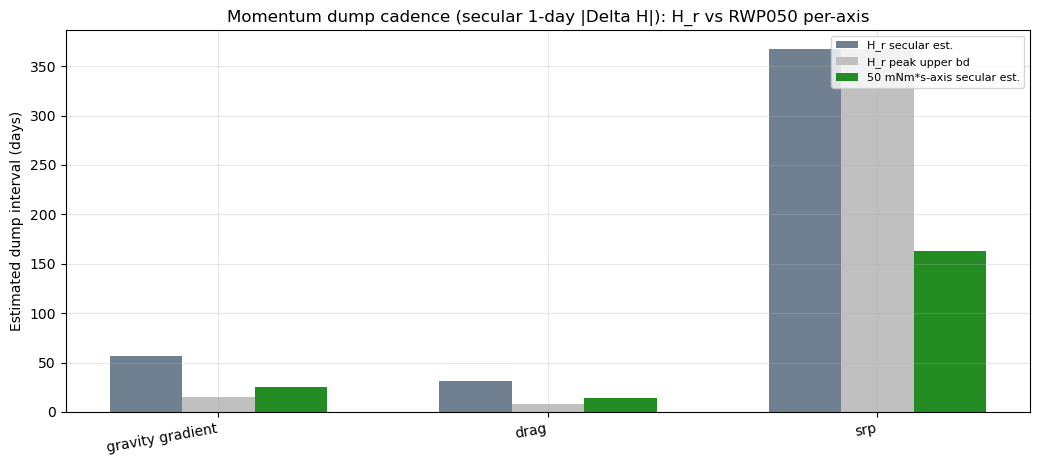

In [209]:
fig_dump, ax_dump = subplots(1, 1, figsize=(10.5, 4.75))
bw = 0.22
x = 1:length(summary_labels)

ax_dump.bar((x .- bw), dump_days_Hr_secular, width=bw, label="H_r secular est.", color="slategray")
ax_dump.bar(x, dump_days_Hr_upper, width=bw, label="H_r peak upper bd", color="silver")
ax_dump.bar((x .+ bw), dump_days_wheel_axis_secular, width=bw, label="50 mNm*s-axis secular est.", color="forestgreen")

ax_dump.set_xticks(collect(x))
ax_dump.set_xticklabels(summary_labels, rotation=10, ha="right")
ax_dump.set_ylabel("Estimated dump interval (days)")
ax_dump.set_title("Momentum dump cadence (secular 1-day |Delta H|): H_r vs RWP050 per-axis")
ax_dump.legend(loc="upper right", fontsize=8)
ax_dump.grid(true, alpha=0.3)
fig_dump.tight_layout()

savefig("figs/momuntumdumpingcadence.png", bbox_inches="tight")
display(fig_dump)


### Coupled Multi-Orbit Propagation

State: \([r;\,v;\,q;\,\omega]\), two-body + J2 + drag. SRP omitted (480 km LEO, drag dominates). Scenarios A–D: baseline, +GG only, +drag only, +GG+drag — same ICs, perturbations toggled.

In [210]:
Random.seed!(54321)
n_orbits_coupled = 5
t_end_coupled = n_orbits_coupled * orbit_period_s

delta_w_p = 0.01 * omega_des
xis = SVector(1.0, 0.0, 0.0)
xisn = normalize(xis - dot(xis, e_panel) * e_panel)
w0_coupled = w_des + delta_w_p * xisn

x0_coupled = zeros(13)
x0_coupled[1:3] .= r0_km
x0_coupled[4:6] .= v0_kmps
x0_coupled[7:10] .= q0_orbit
x0_coupled[11:13] .= w0_coupled

e_hat = normalize(SVector{3,Float64}(e_panel))

scenario_defs = [
    ("A baseline: J2+two-body, no env wrench", false, false),
    ("B +gravity gradient only", true, false),
    ("C +drag force/torque only", false, true),
    ("D +GG + drag (LEO env model)", true, true),
]

sols_env = Dict{String,Any}()
for (label, gg, dr) in scenario_defs
    params = OrbitGyrostatEnvParams(;
        I = I_pert,
        H_r = H_r,
        e = e_hat,
        env = env,
        aero = aero,
        include_gg = gg,
        include_drag = dr,
    )
    sol = integrate_orbit_gyrostat_env!(
        x0_coupled, params;
        tspan=(0.0, t_end_coupled),
        saveat=60.0,
        reltol=1e-8,
        abstol=1e-11,
    )
    sols_env[label] = sol
    println(label, "  ->  steps saved=", length(sol.t), ",  tf[h]=", round(sol.t[end] / 3600; digits=3))
end

A baseline: J2+two-body, no env wrench  ->  steps saved=473,  tf[h]=7.85
B +gravity gradient only  ->  steps saved=473,  tf[h]=7.85
C +drag force/torque only  ->  steps saved=473,  tf[h]=7.85
D +GG + drag (LEO env model)  ->  steps saved=473,  tf[h]=7.85


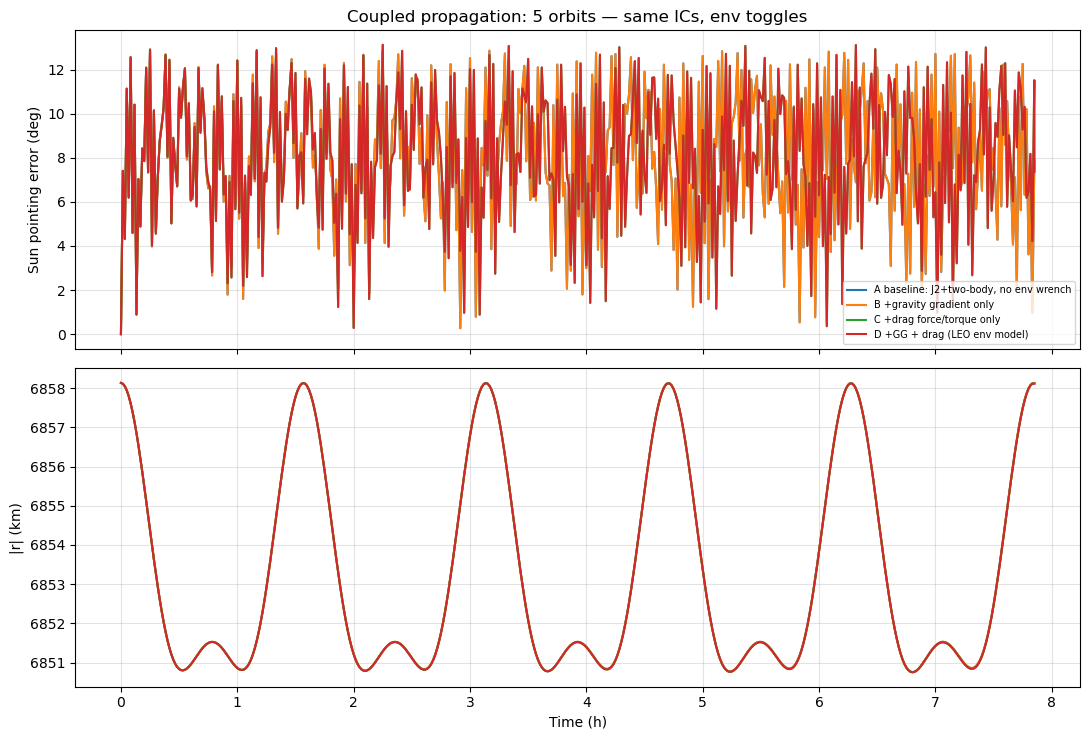

Python: None

In [211]:
function radius_km_from_sol(sol)
    return [hypot(u[1], u[2], u[3]) for u in sol.u]
end

fig_c, ax_c = subplots(2, 1, figsize=(11, 7.5), sharex=true)
for (label, _, _) in scenario_defs
    sol = sols_env[label]
    th = sol.t ./ 3600.0
    pe_deg = pointing_error(sol, e_panel, sun_vec_eci)
    ax_c[0].plot(th, pe_deg; label=label)
end
ax_c[0].set_ylabel("Sun pointing error (deg)")
ax_c[0].set_title("Coupled propagation: $(n_orbits_coupled) orbits — same ICs, env toggles")
ax_c[0].legend(loc="best", fontsize=7)
ax_c[0].grid(true, alpha=0.35)

for (label, _, _) in scenario_defs
    sol = sols_env[label]
    th = sol.t ./ 3600.0
    ax_c[1].plot(th, radius_km_from_sol(sol); label=label)
end
ax_c[1].set_ylabel("|r| (km)")
ax_c[1].set_xlabel("Time (h)")
ax_c[1].grid(true, alpha=0.35)

fig_c.tight_layout()

## §3 — Attitude Regulation

In [212]:
dt_ctrl = 0.25
g_pd    = PDGains(2.5, 3.5)

sigma_gyro      = 0.002
sigma_vec       = 0.01
sigma_bias_walk = 1e-5
V_mekf = Diagonal(fill(max((sigma_gyro * dt_ctrl)^2, 1e-10), 3))

qd = Vector(quat_normalize(@SVector [1.0, 0.0, 0.0, 0.0]))

println("kp = ", g_pd.kp, "  kd = ", g_pd.kd)
println("sigma_gyro = ", sigma_gyro, "  sigma_vec = ", sigma_vec)


kp = 2.5  kd = 3.5
sigma_gyro = 0.002  sigma_vec = 0.01


mean RMS = 132.5167°,  max = 137.0536°


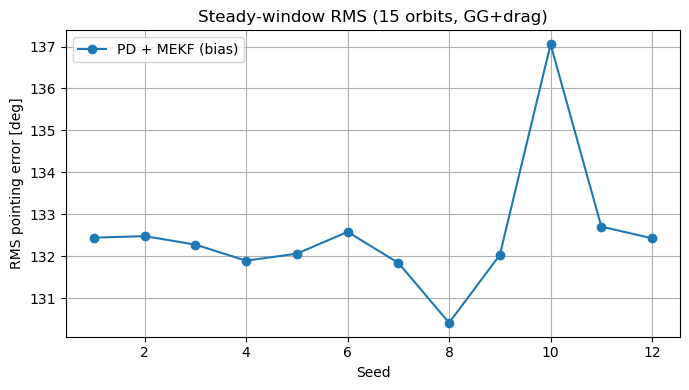

Python: None

In [213]:
T_orbit_s = 2pi / cfg.mean_motion_rad_s
n_orbits  = 15
T_mc      = n_orbits * T_orbit_s
Nseeds    = 12
rms_pd    = Float64[]

for s in 1:Nseeds
    rng    = MersenneTwister(100 + s)
    q0     = Vector(random_quat_max_angle(deg2rad(90)))
    omega0 = 0.02 .* randn(rng, 3)
    rho0   = 0.01 .* cfg.rho_rw_max .* randn(rng, 3)
    sol    = simulate_closed_loop(
        cfg;
        Tfinal=T_mc, dt=dt_ctrl, q0=q0, omega0=omega0, rho0=rho0, qd=qd,
        g=g_pd, sigma_gyro=sigma_gyro, sigma_vec=sigma_vec, V_mekf=V_mekf, rng=rng,
        control_gyro_lpf_tau=0.5, professor_mekf=true, sigma_bias_walk=sigma_bias_walk,
    )
    push!(rms_pd, rms_steady(collect(sol.ang_hist); skip_frac=0.2))
end

println("mean RMS = ", round(mean(rms_pd), digits=4), "°,  max = ", round(maximum(rms_pd), digits=4), "°")

figure(figsize=(7, 4))
plot(1:Nseeds, rms_pd, "o-", label="PD + MEKF (bias)")
xlabel("Seed"); ylabel("RMS pointing error [deg]")
title("Steady-window RMS ($n_orbits orbits, GG+drag)")
legend(); grid(true); tight_layout()
savefig("figs/RMSpointingerror.png", bbox_inches="tight")


## §4 — Eigen-Axis Slew

### Quaternion Utilities

In [214]:
function hat(v)
    return [0 -v[3] v[2];
            v[3] 0 -v[1];
            -v[2] v[1] 0]
end

function unhat(S)
    return 0.5*[S[3,2]-S[2,3];
                S[1,3]-S[3,1];
                S[2,1]-S[1,2]]
end

H = [zeros(1,3); I];
T_q = [1  zeros(1,3);
       zeros(3,1) -I];

function L(q)
    return [q[1]          -q[2:4]';
            q[2:4]    q[1]*I + hat(q[2:4])]
end

function R(q)
    return [q[1]          -q[2:4]';
            q[2:4]    q[1]*I - hat(q[2:4])]
end

function G(q)
    return L(q)*H
end

function Q(q)
    return H'*(R(q)'*L(q))*H
end

function expq(ϕ)
    θ = norm(ϕ)
    return [cos(θ); ϕ*sinc(θ/π)]
end

function logq(q)
    θ = acos(clamp(q[1], -1.0, 1.0))
    n = norm(q[2:4])
    return n < 1e-10 ? zeros(3) : θ * q[2:4] / n
end

logq (generic function with 2 methods)

### MEKF

In [215]:
function state_prediction(x,u,h)
    q = x[1:4]
    β = x[5:7]
    ω = u-β
    Δq = expq(0.5*h*ω)
    return [L(q)*Δq; β]
end

function state_prediction_deriv(x,u,h)
    q = x[1:4]
    β = x[5:7]
    ω = u-β
    Δq = expq(0.5*h*ω)
    qn = L(q)*Δq
    A = [G(qn)'*R(Δq)*G(q) -0.5*h*G(qn)'*G(q);
         zeros(3,3)            I(3)]
    return A
end

function measurement_prediction(x,r_N)
    q = x[1:4]
    Qk = Q(q)
    y = Qk'*r_N
    return y[:]
end

function measurement_prediction_deriv(x,r_N)
    q = x[1:4]
    m = size(r_N,2)
    C = zeros(3*m,6)
    for k = 1:m
        C[((k-1)*3).+(1:3),1:3] .= H'*(L(q)'*L(H*r_N[:,k]) + R(q)*R(H*r_N[:,k])*T_q)*G(q)
    end
    return C
end

measurement_prediction_deriv (generic function with 1 method)

### Spacecraft Parameters

In [216]:
J     = Diagonal([0.14, 0.195, 0.249])  # principal moments of inertia [kg·m²]
τ_max = 6e-3    # max reaction wheel torque [N·m]
ρ_max = 50e-3   # max reaction wheel momentum [N·m·s]

0.05

### Eigen-Axis Slew: Versine Trajectory

In [217]:
function versine_traj(q0, qd, T, t)
    # Rotation we must perform: from q0 to qd, expressed in q0's body frame
    q_e = L(q0)' * qd   # = q0⁻¹ ⊗ qd

    # Ensure positive scalar part (short-arc convention)
    if q_e[1] < 0
        q_e = -q_e
    end

    # φ_f = 2*logq(q_e) is the full rotation vector (logq returns half-angle × axis)
    ϕ_f = 2 * logq(q_e)
    θ_f = norm(ϕ_f)
    r̂   = ϕ_f / θ_f

    α = π / T

    θ      = θ_f/2 * (1 - cos(α*t))
    θ_dot  = θ_f/2 * α * sin(α*t)
    θ_ddot = θ_f/2 * α^2 * cos(α*t)

    # Compose incremental rotation with q0: q_nom(0)=q0, q_nom(T)=qd
    q_rel = expq((θ/2) * r̂)   # expq takes half-angle × axis
    q_nom = L(q0) * q_rel
    q_nom = q_nom / norm(q_nom)

    ω_nom    = θ_dot  * r̂
    ωdot_nom = θ_ddot * r̂

    return q_nom, ω_nom, ωdot_nom
end

versine_traj (generic function with 1 method)

### Inverse Dynamics & Feasibility Check

In [218]:
# 180° slew from identity to a rotation about the b3 axis
q0 = [1.0; 0; 0; 0]
qd = [0.0; 0; 0; 1]   # 180° about b3: q = [cos(π/2); sin(π/2)*ê3] = [0;0;0;1]
T  = 60.0              # maneuver time [s]
dt = 0.01              # time step [s]
ts = 0:dt:T

# Evaluate nominal trajectory at each timestep
N = length(ts)
q_nom_hist    = zeros(4, N)
ω_nom_hist    = zeros(3, N)
ωdot_nom_hist = zeros(3, N)

for (i, t) in enumerate(ts)
    q_nom_hist[:,i], ω_nom_hist[:,i], ωdot_nom_hist[:,i] = versine_traj(q0, qd, T, t)
end

# Integrate inverse dynamics: ρ̇ = -J*ω̇ - ω × (J*ω + ρ), with B_w = I so u = ρ̇
ρ_hist = zeros(3, N)
u_hist = zeros(3, N)

ρ = zeros(3)
for i in 1:N
    ω  = ω_nom_hist[:,i]
    ωd = ωdot_nom_hist[:,i]
    ρ_dot = -J*ωd - cross(ω, J*ω + ρ)
    u_hist[:,i] = ρ_dot
    ρ_hist[:,i] = ρ
    if i < N
        ρ = ρ + dt * ρ_dot
    end
end

println("Peak wheel torque:    $(round(maximum(abs.(u_hist))*1e3, digits=2)) mN·m  (limit: $(τ_max*1e3) mN·m)")
println("Peak wheel momentum:  $(round(maximum(abs.(ρ_hist))*1e3, digits=2)) mN·m·s  (limit: $(ρ_max*1e3) mN·m·s)")

Peak wheel torque:    1.07 mN·m  (limit: 6.0 mN·m)
Peak wheel momentum:  20.48 mN·m·s  (limit: 50.0 mN·m·s)


### Closed-Loop Simulation

In [219]:
# True gyrostat dynamics: state = [q(1:4); ω(5:7); ρ(8:10)]
# J*ω̇ = -u - ω×(Jω + ρ),  ρ̇ = u,  q̇ = 0.5*G(q)*ω
function spacecraft_dynamics(state, u, J)
    q = state[1:4]
    ω = state[5:7]
    ρ = state[8:10]
    qdot = 0.5 * G(q) * ω
    ωdot = -J \ (u + cross(ω, J*ω + ρ))
    ρdot = u
    return [qdot; ωdot; ρdot]
end

function rk4_step(state, u, dt, J)
    k1 = spacecraft_dynamics(state, u, J)
    k2 = spacecraft_dynamics(state + dt/2 * k1, u, J)
    k3 = spacecraft_dynamics(state + dt/2 * k2, u, J)
    k4 = spacecraft_dynamics(state + dt * k3, u, J)
    s  = state + dt/6 * (k1 + 2k2 + 2k3 + k4)
    s[1:4] /= norm(s[1:4])
    return s
end

rk4_step (generic function with 2 methods)

In [220]:
# Simulation timestep and duration
dt_cl = 0.1        # [s] — 10 Hz, matches MEKF update rate
T_sim  = T + 20.0  # [s] — slew duration plus settling window
N_cl   = round(Int, T_sim / dt_cl) + 1
ts_cl  = range(0.0, T_sim, length=N_cl)

# Two fixed inertial reference vectors for MEKF measurements (sun + field proxy)
r_N_ref = [1.0 0.0; 0.0 1.0; 0.0 0.0]

# Noise standard deviations
σ_gyro = 3.13e-4   # gyro measurement noise [rad/s]
σ_bias = 4.16e-7   # gyro bias random walk per step [rad/s]
σ_meas = 5.24e-3   # vector measurement noise [rad, ~0.3°]

# MEKF noise covariances
V_proc = Diagonal([σ_gyro^2 * ones(3); σ_bias^2 * ones(3)])
W_meas = σ_meas^2 * I(6)

# PD feedback gains (ωn ≈ 0.18 rad/s, critically damped)
Kp = 5e-3 * I(3)   # [N·m / rad]
Kd = 6e-2 * I(3)   # [N·m·s / rad]

# Initial gyro bias (small, unknown to filter initially)
β_true_init = [1.75e-4; -8.73e-5; 1.40e-4]  # ~0.01 deg/s

3-element Vector{Float64}:
  0.000175
 -8.73e-5
  0.00014

In [221]:
Random.seed!(42)

# --- True state ---
state_true = [q0; zeros(3); zeros(3)]   # [q; ω; ρ]
β_true     = copy(β_true_init)

# --- MEKF state ---
x̂ = [q0; zeros(3)]
P = Diagonal([0.5*ones(3); 1.0*ones(3)])

# --- Nominal wheel momentum ---
ρ_nom = zeros(3)

# --- History buffers ---
q_cl     = zeros(4, N_cl)
ω_cl     = zeros(3, N_cl)
ρ_cl     = zeros(3, N_cl)
u_cl     = zeros(3, N_cl)
u_des_cl = zeros(3, N_cl)   # desired torque before saturation
q_nom_cl = zeros(4, N_cl)
ω_nom_cl = zeros(3, N_cl)
φ_err_cl = zeros(3, N_cl)

for i in 1:N_cl
    t = ts_cl[i]

    q_cl[:,i] = state_true[1:4]
    ω_cl[:,i] = state_true[5:7]
    ρ_cl[:,i] = state_true[8:10]

    if t >= T
        q_nom_i, ω_nom_i, ωdot_nom_i = qd, zeros(3), zeros(3)
    else
        q_nom_i, ω_nom_i, ωdot_nom_i = versine_traj(q0, qd, T, t)
    end
    # t_nom = min(t, T)
    # q_nom_i, ω_nom_i, ωdot_nom_i = versine_traj(q0, qd, T, t_nom)
    q_nom_cl[:,i] = q_nom_i
    ω_nom_cl[:,i] = ω_nom_i

    u_nom_i = -J * ωdot_nom_i - cross(ω_nom_i, J * ω_nom_i + ρ_nom)

    u_gyro = state_true[5:7] + β_true + randn(3) * σ_gyro

    x̂_pred = state_prediction(x̂, u_gyro, dt_cl)
    A       = state_prediction_deriv(x̂, u_gyro, dt_cl)
    P_pred  = A * P * A' + V_proc

    y_meas = measurement_prediction([state_true[1:4]; zeros(3)], r_N_ref) + randn(6) * σ_meas

    C  = measurement_prediction_deriv(x̂_pred, r_N_ref)
    S  = C * P_pred * C' + W_meas
    K  = P_pred * C' / S
    Δx = K * (y_meas - measurement_prediction(x̂_pred, r_N_ref))
    ϕ  = Δx[1:3]
    Δq = [sqrt(1 - ϕ'ϕ); ϕ]
    x̂  = [L(x̂_pred[1:4]) * Δq; x̂_pred[5:7] + Δx[4:6]]
    P  = (I(6) - K*C) * P_pred * (I(6) - K*C)' + K * W_meas * K'

    ω_est = u_gyro - x̂[5:7]

    # At i=1, nominal and true both start at q0 so error is identity — skip logq
    if i == 1
        φ_e = zeros(3)
    else
        q_e = L(q_nom_i)' * x̂[1:4]
        if q_e[1] < 0; q_e = -q_e; end
        φ_e = 2 * logq(q_e)
    end
    φ_err_cl[:,i] = φ_e

    ω_e = ω_est - ω_nom_i

    δu = Kp * φ_e + Kd * ω_e
    u_des_cl[:,i] = u_nom_i + δu          # desired (before saturation)
    u_total = clamp.(u_nom_i + δu, -τ_max, τ_max)
    u_cl[:,i] = u_total

    if i < N_cl
        state_true = rk4_step(state_true, u_total, dt_cl, J)
        β_true    += randn(3) * σ_bias
        ρ_nom     += dt_cl * u_nom_i
    end
end

φ_final = norm(φ_err_cl[:,end]) * 180/π
println("Final attitude error: $(round(φ_final, digits=4))°")

Final attitude error: 0.1285°


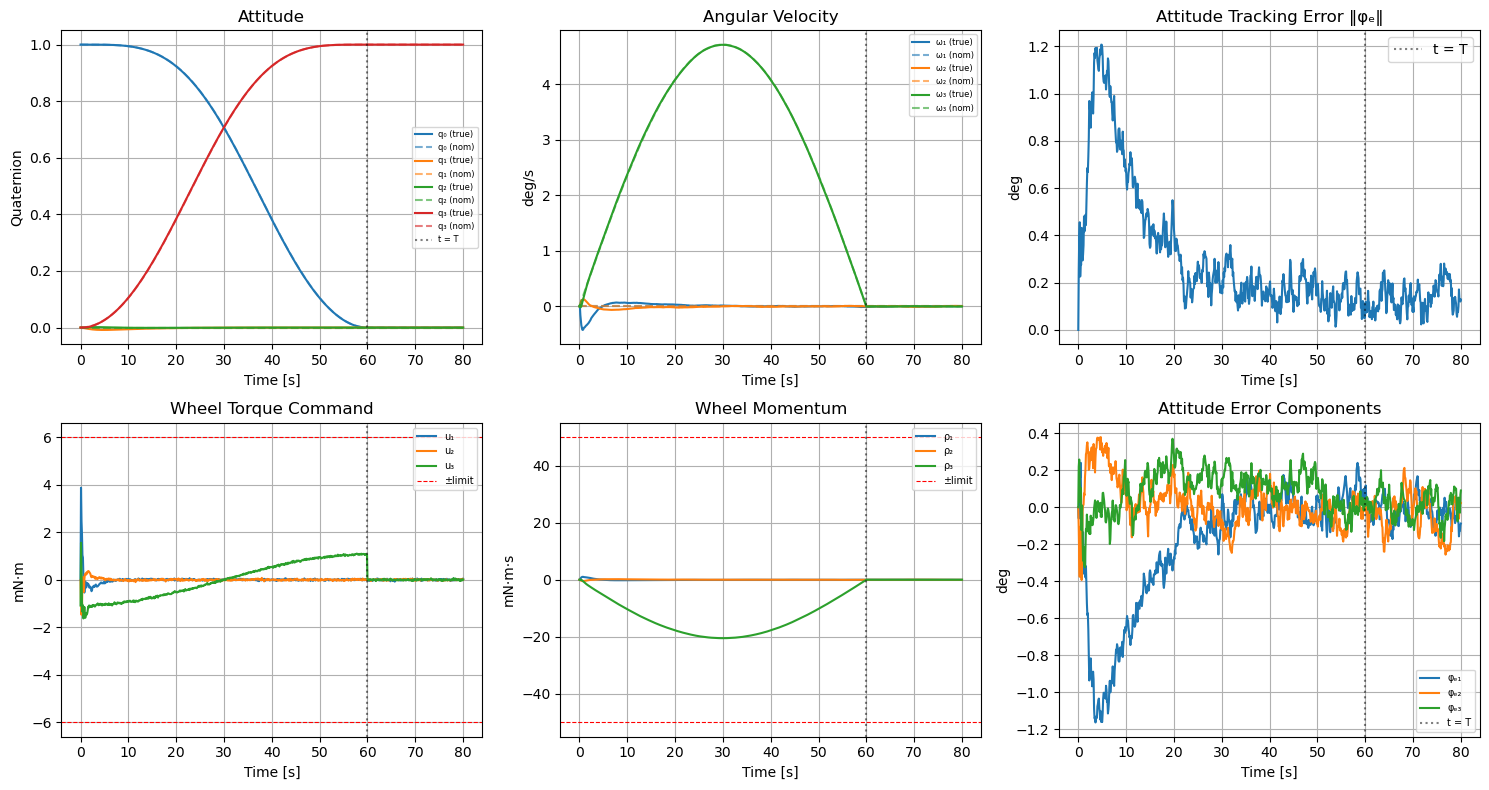

In [ ]:
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = subplots(2, 3, figsize=(15, 8))

for (i, lbl) in enumerate(["q₀","q₁","q₂","q₃"])
    l = ax1.plot(ts_cl, q_cl[i,:], label=lbl * " (true)")
    ax1.plot(ts_cl, q_nom_cl[i,:], "--", color=l[0].get_color(), alpha=0.6, label=lbl * " (nom)")
end
ax1.axvline(T, color="k", linestyle=":", alpha=0.5, label="t = T")
ax1.set_xlabel("Time [s]"); ax1.set_ylabel("Quaternion"); ax1.set_title("Attitude")
ax1.legend(fontsize=6); ax1.grid(true)

for (i, lbl) in enumerate(["ω₁","ω₂","ω₃"])
    l = ax2.plot(ts_cl, ω_cl[i,:]*180/π, label=lbl * " (true)")
    ax2.plot(ts_cl, ω_nom_cl[i,:]*180/π, "--", color=l[0].get_color(), alpha=0.6, label=lbl * " (nom)")
end
ax2.axvline(T, color="k", linestyle=":", alpha=0.5)
ax2.set_xlabel("Time [s]"); ax2.set_ylabel("deg/s"); ax2.set_title("Angular Velocity")
ax2.legend(fontsize=6); ax2.grid(true)

err_deg = [norm(φ_err_cl[:,i])*180/π for i in 1:N_cl]
ax3.plot(ts_cl, err_deg)
ax3.axvline(T, color="k", linestyle=":", alpha=0.5, label="t = T")
ax3.set_xlabel("Time [s]"); ax3.set_ylabel("deg"); ax3.set_title("Attitude Tracking Error ‖φₑ‖")
ax3.legend(); ax3.grid(true)

for (i, lbl) in enumerate(["u₁","u₂","u₃"])
    ax4.plot(ts_cl, u_cl[i,:]*1e3, label=lbl)
end
ax4.axhline( τ_max*1e3, color="r", linestyle="--", label="limit")
ax4.axhline(-τ_max*1e3, color="r", linestyle="--")
ax4.axvline(T, color="k", linestyle=":", alpha=0.5)
ax4.set_xlabel("Time [s]"); ax4.set_ylabel("mN·m"); ax4.set_title("Wheel Torque Command")
ax4.legend(fontsize=7); ax4.grid(true)

for (i, lbl) in enumerate(["ρ₁","ρ₂","ρ₃"])
    ax5.plot(ts_cl, ρ_cl[i,:]*1e3, label=lbl)
end
ax5.axhline( ρ_max*1e3, color="r", linestyle="--", label="limit")
ax5.axhline(-ρ_max*1e3, color="r", linestyle="--")
ax5.axvline(T, color="k", linestyle=":", alpha=0.5)
ax5.set_xlabel("Time [s]"); ax5.set_ylabel("mN·m·s"); ax5.set_title("Wheel Momentum")
ax5.legend(fontsize=7); ax5.grid(true)

for (i, lbl) in enumerate(["φₑ₁","φₑ₂","φₑ₃"])
    ax6.plot(ts_cl, φ_err_cl[i,:]*180/π, label=lbl)
end
ax6.axvline(T, color="k", linestyle=":", alpha=0.5, label="t = T")
ax6.set_xlabel("Time [s]"); ax6.set_ylabel("deg"); ax6.set_title("Attitude Error Components")
ax6.legend(fontsize=7); ax6.grid(true)

tight_layout()
savefig("figs/eigenaxis_closedloop.pdf", bbox_inches="tight")
display(fig)

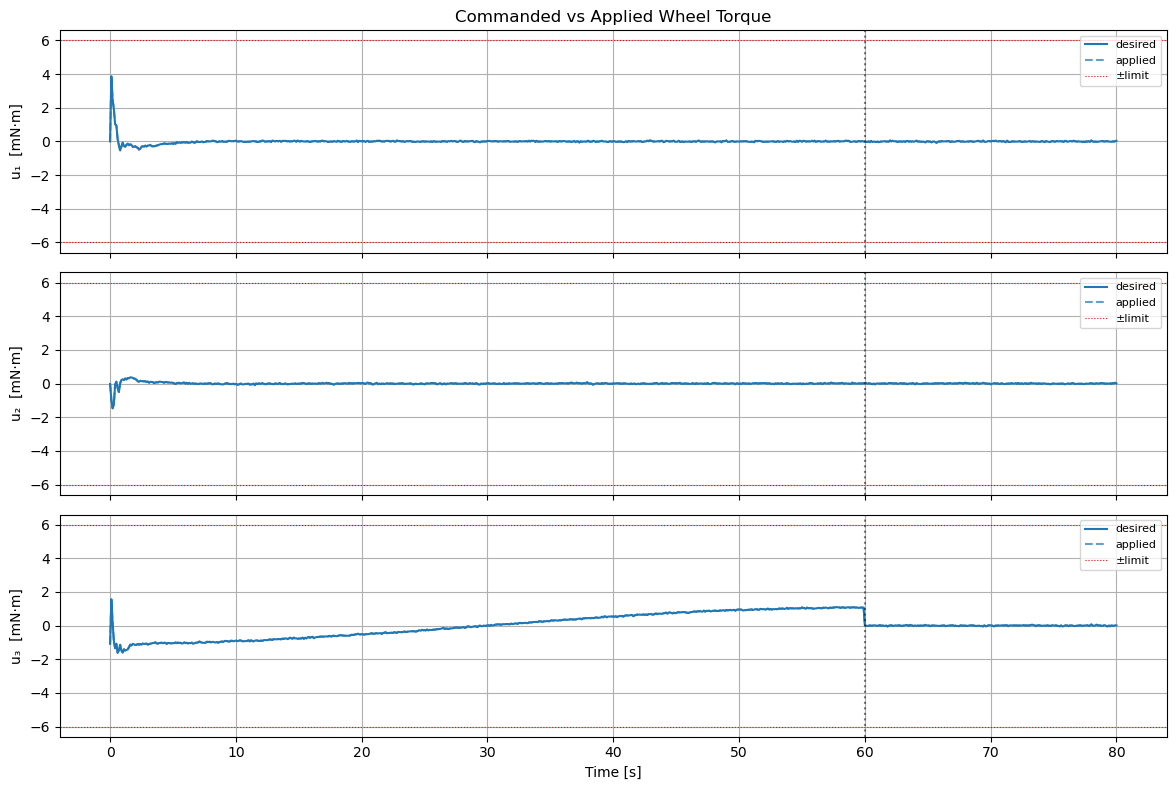

In [ ]:
fig, axs = subplots(3, 1, figsize=(12, 8), sharex=true)

lbls = ["u₁","u₂","u₃"]
for (i, lbl) in enumerate(lbls)
    l = axs[i-1].plot(ts_cl, u_des_cl[i,:]*1e3, label="desired")
    axs[i-1].plot(ts_cl, u_cl[i,:]*1e3, "--", color=l[0].get_color(), alpha=0.7, label="applied")
    axs[i-1].axhline( τ_max*1e3, color="r", linestyle=":", label="limit")
    axs[i-1].axhline(-τ_max*1e3, color="r", linestyle=":")
    axs[i-1].axvline(T, color="k", linestyle=":", alpha=0.5)
    axs[i-1].set_ylabel("$lbl  [mN·m]")
    axs[i-1].legend(fontsize=8); axs[i-1].grid(true)
end

axs[0].set_title("Commanded vs Applied Wheel Torque")
axs[2].set_xlabel("Time [s]")
tight_layout()
savefig("figs/eigenaxis_input_vs_applied.pdf", bbox_inches="tight")
display(fig)

In [224]:
# Slew feasibility test: vary T and rotation axis
# Peak torque scales 1/T², peak momentum scales 1/T — both should saturate at fast T
test_cases = [
    ("180° b3,        T=60s",  [1.0;0;0;0], [0.0;0;0;1],       60.0),
    ("180° b3,        T=15s",  [1.0;0;0;0], [0.0;0;0;1],       15.0),
    ("120° [1,1,1],   T=60s",  [1.0;0;0;0], [0.5;0.5;0.5;0.5], 60.0),
    ("120° [1,1,1],   T=15s",  [1.0;0;0;0], [0.5;0.5;0.5;0.5], 15.0),
]

println("Case                      | peak τ [mN·m] | peak ρ [mN·m·s] | feasible?")
println("-"^75)
for (label, q0_, qd_, T_) in test_cases
    ts_ = 0:0.01:T_
    ρ_ = zeros(3); pt = 0.0; pm = 0.0
    for (i, t) in enumerate(ts_)
        _, ω_, ωd_ = versine_traj(q0_, qd_, T_, t)
        ρ_dot = -J*ωd_ - cross(ω_, J*ω_ + ρ_)
        pt = max(pt, maximum(abs.(ρ_dot)))
        pm = max(pm, maximum(abs.(ρ_)))
        i < length(ts_) && (ρ_ += 0.01*ρ_dot)
    end
    ok = pt ≤ τ_max && pm ≤ ρ_max
    verdict = ok ? "Y" : "N  (τ: $(round(pt/τ_max,digits=1)) x limit, ρ: $(round(pm/ρ_max,digits=1)) x limit)"
    println("$(rpad(label,26))| $(rpad(round(pt*1e3,digits=2),14))| $(rpad(round(pm*1e3,digits=2),16))| $verdict")
end

Case                      | peak τ [mN·m] | peak ρ [mN·m·s] | feasible?
---------------------------------------------------------------------------
180° b3,        T=60s     | 1.07          | 20.48           | Y
180° b3,        T=15s     | 17.16         | 82.0            | N  (τ: 2.9 x limit, ρ: 1.6 x limit)
120° [1,1,1],   T=60s     | 0.41          | 7.88            | Y
120° [1,1,1],   T=15s     | 6.6           | 31.56           | N  (τ: 1.1 x limit, ρ: 0.6 x limit)


## §5 — Regulator vs. Eigen-Axis Slew: Large-Angle Comparison

In [225]:
# ─── Scenario: 150° initial error about [1,1,1]/√3 ────────────────────────────
θ_far  = deg2rad(150.0)
ax_far = normalize([1.0, 1.0, 1.0])
q0_far = [cos(θ_far/2); ax_far .* sin(θ_far/2)]
qd_cmp = [1.0, 0.0, 0.0, 0.0]   # target: identity

T_slew_c   = 60.0    # versine maneuver time [s] — same as §4
kp_c, kd_c = 5e-3, 6e-2   # same PD gains used in §4 tracking controller

# ─── Versine feasibility for 150° in T_slew_c ─────────────────────────────────
ts_v = 0.0:0.01:T_slew_c
ρ_v = zeros(3); pt_v = 0.0; pm_v = 0.0
for (k_, t_) in enumerate(ts_v)
    _, ω_, ωd_ = versine_traj(q0_far, qd_cmp, T_slew_c, t_)
    ρd_ = -J * ωd_ .- cross(ω_, J * ω_ .+ ρ_v)
    pt_v = max(pt_v, maximum(abs.(ρd_)))
    pm_v = max(pm_v, maximum(abs.(ρ_v)))
    k_ < length(ts_v) && (ρ_v .+= 0.01 .* ρd_)
end
println("Versine feasibility (150°, T=$(Int(T_slew_c)) s):")
println("  peak |τ| = $(round(pt_v*1e3, digits=2)) mN·m   (limit $(τ_max*1e3) mN·m)   $(pt_v ≤ τ_max ? "✓ feasible" : "✗ EXCEEDS")")
println("  peak |ρ| = $(round(pm_v*1e3, digits=1)) mN·m·s  (limit $(ρ_max*1e3) mN·m·s)  $(pm_v ≤ ρ_max ? "✓ feasible" : "✗ EXCEEDS")")

# ─── Regulator initial torque demand ──────────────────────────────────────────
q_ef0 = L(qd_cmp)' * q0_far
if q_ef0[1] < 0; q_ef0 = -q_ef0; end
φ_ef0 = 2.0 .* logq(q_ef0)
τ_init_reg = kp_c * norm(φ_ef0)
println("\nRegulator at t=0:")
println("  |φ_e| = $(round(norm(φ_ef0), digits=3)) rad  ($(round(rad2deg(norm(φ_ef0)/2), digits=1))° principal angle)")
println("  |τ_des| = $(round(τ_init_reg*1e3, digits=2)) mN·m  ($(round(τ_init_reg/τ_max, digits=1))× τ_max  →  saturates immediately)")
println("  Theoretical ρ_max in: $(round(ρ_max / τ_max, digits=1)) s  if τ_max sustained (actual peak ≈ 30 mN·m·s — kd braking exits saturation at t≈5 s)")

Versine feasibility (150°, T=60 s):
  peak |τ| = 0.52 mN·m   (limit 6.0 mN·m)   ✓ feasible
  peak |ρ| = 9.9 mN·m·s  (limit 50.0 mN·m·s)  ✓ feasible

Regulator at t=0:
  |φ_e| = 2.618 rad  (75.0° principal angle)
  |τ_des| = 13.09 mN·m  (2.2× τ_max  →  saturates immediately)
  Theoretical ρ_max in: 8.3 s  if τ_max sustained (actual peak ≈ 30 mN·m·s — kd braking exits saturation at t≈5 s)


In [226]:
# ─── Unified comparison simulation ────────────────────────────────────────────
# Dynamics: ωdot = −J\(u + ω×(Jω+ρ)),  ρdot = u  (§4 convention: u = wheel command)
# Regulator:  τ_des = +kp·φ_ef + kd·ω           (no reference trajectory)
# Slew:       τ_des = u_nom + kp·φ_track + kd·ω_track  (versine feedforward + tracking PD)
# Both use the same gains; the slew relies on the feedforward for large-angle actuation.

function run_compare_sim(mode::Symbol, q0_ic::Vector{Float64}, qd_ic::Vector{Float64},
                          T_sim::Float64, T_sl::Float64;
                          dt::Float64=0.1, kp::Float64=5e-3, kd::Float64=6e-2)
    N     = round(Int, T_sim / dt) + 1
    ts_   = collect(range(0.0, T_sim; length=N))
    st    = [copy(q0_ic); zeros(3); zeros(3)]   # [q(4); ω(3); ρ(3)]
    ρ_nom = zeros(3)   # nominal wheel momentum (slew only)

    ang_h   = zeros(N)     # principal angle to qd [deg]
    u_sat_h = zeros(3, N)  # applied (saturated) torque
    u_des_h = zeros(3, N)  # desired torque before saturation

    for i in 1:N
        t_ = ts_[i]
        q_ = st[1:4];  ω_ = st[5:7]

        # Principal angle to final target
        q_ef = L(qd_ic)' * q_
        if q_ef[1] < 0; q_ef = -q_ef; end
        ang_h[i] = norm(2.0 .* logq(q_ef)) * 180 / π

        u_nom_i = zeros(3)
        if mode === :regulator
            # PD regulator: positive gains drive q → qd via wheel spin-up
            τ_des = kp .* (2.0 .* logq(q_ef)) .+ kd .* ω_

        else  # :slew — versine feedforward + tracking PD
            if t_ >= T_sl
                q_n, ω_n, ωd_n = copy(qd_ic), zeros(3), zeros(3)
            else
                q_n, ω_n, ωd_n = versine_traj(q0_ic, qd_ic, T_sl, t_)
            end
            # Inverse-dynamics feedforward (same expression as §4)
            u_nom_i = -J * ωd_n .- cross(ω_n, J * ω_n .+ ρ_nom)
            # Tracking error relative to the nominal trajectory
            q_et = L(q_n)' * q_
            if q_et[1] < 0; q_et = -q_et; end
            τ_des = u_nom_i .+ kp .* (2.0 .* logq(q_et)) .+ kd .* (ω_ .- ω_n)
        end

        u_des_h[:, i] = τ_des
        u_c = clamp.(τ_des, -τ_max, τ_max)
        u_sat_h[:, i] = u_c

        if i < N
            st = rk4_step(st, u_c, dt, J)
            mode === :slew && t_ < T_sl && (ρ_nom .+= dt .* u_nom_i)
        end
    end
    return (; ts=ts_, ang_h, u_sat_h, u_des_h)
end

# ─── Run: 150° large-angle IC ─────────────────────────────────────────────────
res_reg  = run_compare_sim(:regulator, q0_far, qd_cmp, 300.0,            T_slew_c; dt=0.1, kp=kp_c, kd=kd_c)
res_slew = run_compare_sim(:slew,      q0_far, qd_cmp, T_slew_c + 60.0, T_slew_c; dt=0.1, kp=kp_c, kd=kd_c)

# ─── Run: 15° near-angle IC ────────────────────────────────────────────────────
θ_near  = deg2rad(15.0)
q0_near = [cos(θ_near/2); normalize([1.0, 0.0, 0.0]) .* sin(θ_near/2)]
res_reg_n  = run_compare_sim(:regulator, q0_near, qd_cmp, 150.0, T_slew_c; dt=0.1, kp=kp_c, kd=kd_c)
res_slew_n = run_compare_sim(:slew,      q0_near, qd_cmp, 150.0, T_slew_c; dt=0.1, kp=kp_c, kd=kd_c)

println("150° — Regulator: final $(round(res_reg.ang_h[end],  digits=2))°  at t=$(round(res_reg.ts[end]))s")
println("150° — Slew:      final $(round(res_slew.ang_h[end], digits=2))°  at t=$(round(res_slew.ts[end]))s")
println(" 15° — Regulator: final $(round(res_reg_n.ang_h[end],  digits=2))°  at t=$(round(res_reg_n.ts[end]))s")
println(" 15° — Slew:      final $(round(res_slew_n.ang_h[end], digits=2))°  at t=$(round(res_slew_n.ts[end]))s")

150° — Regulator: final 0.0°  at t=300.0s
150° — Slew:      final 0.0°  at t=120.0s
 15° — Regulator: final 0.0°  at t=150.0s
 15° — Slew:      final 0.0°  at t=150.0s


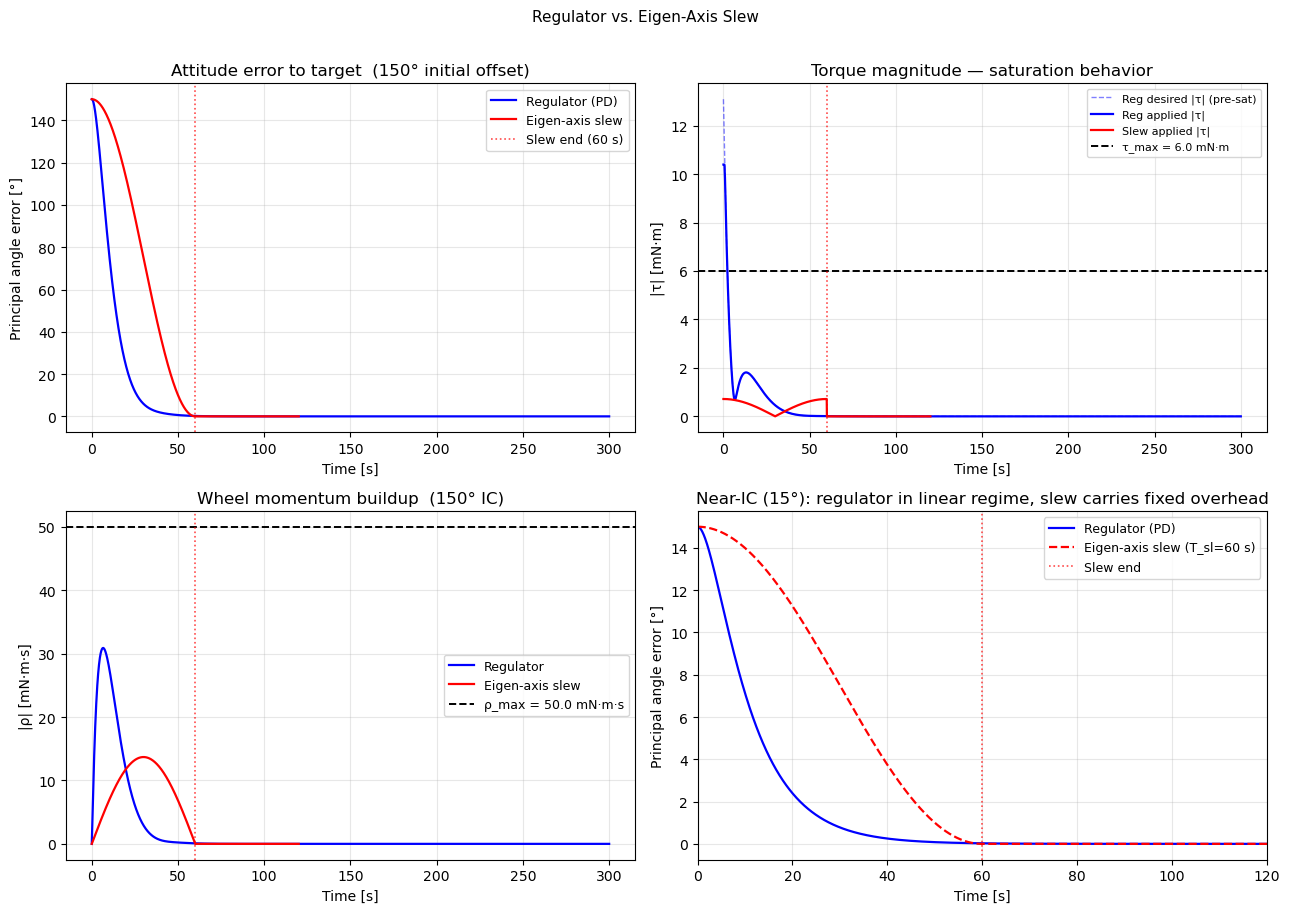

In [227]:
# ─── Helper: integrate applied torque → wheel momentum magnitude history ───────
function wheel_momentum_norm(u_h::Matrix{Float64}, dt_::Float64)
    ρ_ = zeros(3, size(u_h, 2))
    for i in 2:size(u_h, 2)
        ρ_[:, i] = ρ_[:, i-1] .+ dt_ .* u_h[:, i-1]
    end
    return norm.(eachcol(ρ_))   # avoid axes() which is shadowed by PythonPlot
end

fig5, ((ax00, ax01), (ax10, ax11)) = subplots(2, 2, figsize=(13, 9))

# ── (0,0) Principal angle — 150° IC ──────────────────────────────────────────
ax00.plot(res_reg.ts,  res_reg.ang_h,  "b",  lw=1.6, label="Regulator (PD)")
ax00.plot(res_slew.ts, res_slew.ang_h, "r",  lw=1.6, label="Eigen-axis slew")
ax00.axvline(T_slew_c, color="r", ls=":", lw=1.2, alpha=0.7, label="Slew end ($(Int(T_slew_c)) s)")
ax00.set_xlabel("Time [s]")
ax00.set_ylabel("Principal angle error [°]")
ax00.set_title("Attitude error to target  (150° initial offset)")
ax00.legend(fontsize=9);  ax00.grid(true, alpha=0.3)

# ── (0,1) Applied and desired torque magnitude — 150° IC ─────────────────────
τm_reg_des = norm.(eachcol(res_reg.u_des_h))  .* 1e3
τm_reg     = norm.(eachcol(res_reg.u_sat_h))  .* 1e3
τm_slew    = norm.(eachcol(res_slew.u_sat_h)) .* 1e3

ax01.plot(res_reg.ts,  τm_reg_des, "b--", lw=1.0, alpha=0.5, label="Reg desired |τ| (pre-sat)")
ax01.plot(res_reg.ts,  τm_reg,     "b",   lw=1.6,             label="Reg applied |τ|")
ax01.plot(res_slew.ts, τm_slew,    "r",   lw=1.6,             label="Slew applied |τ|")
ax01.axhline(τ_max*1e3, color="k", ls="--", lw=1.4, label="τ_max = $(τ_max*1e3) mN·m")
ax01.axvline(T_slew_c, color="r", ls=":", lw=1.2, alpha=0.7)
ax01.set_xlabel("Time [s]")
ax01.set_ylabel("|τ| [mN·m]")
ax01.set_title("Torque magnitude — saturation behavior")
ax01.legend(fontsize=8);  ax01.grid(true, alpha=0.3)

# ── (1,0) Wheel momentum — 150° IC ───────────────────────────────────────────
ρm_reg  = wheel_momentum_norm(res_reg.u_sat_h,  0.1) .* 1e3
ρm_slew = wheel_momentum_norm(res_slew.u_sat_h, 0.1) .* 1e3

ax10.plot(res_reg.ts,  ρm_reg,  "b", lw=1.6, label="Regulator")
ax10.plot(res_slew.ts, ρm_slew, "r", lw=1.6, label="Eigen-axis slew")
ax10.axhline(ρ_max*1e3, color="k", ls="--", lw=1.4, label="ρ_max = $(ρ_max*1e3) mN·m·s")
ax10.axvline(T_slew_c, color="r", ls=":", lw=1.2, alpha=0.7)
ax10.set_xlabel("Time [s]")
ax10.set_ylabel("|ρ| [mN·m·s]")
ax10.set_title("Wheel momentum buildup  (150° IC)")
ax10.legend(fontsize=9);  ax10.grid(true, alpha=0.3)

# ── (1,1) Principal angle — 15° near-IC ──────────────────────────────────────
ax11.plot(res_reg_n.ts,  res_reg_n.ang_h,  "b",   lw=1.6, label="Regulator (PD)")
ax11.plot(res_slew_n.ts, res_slew_n.ang_h, "r--", lw=1.6, label="Eigen-axis slew (T_sl=$(Int(T_slew_c)) s)")
ax11.axvline(T_slew_c, color="r", ls=":", lw=1.2, alpha=0.7, label="Slew end")
ax11.set_xlabel("Time [s]")
ax11.set_ylabel("Principal angle error [°]")
ax11.set_title("Near-IC (15°): regulator in linear regime, slew carries fixed overhead")
ax11.set_xlim(0, 120)
ax11.legend(fontsize=9);  ax11.grid(true, alpha=0.3)

fig5.suptitle("Regulator vs. Eigen-Axis Slew", fontsize=11, y=1.01)
fig5.tight_layout()
savefig("figs/regulator_vs_slew_comparison.pdf", bbox_inches="tight")
display(fig5)